# SVM Hyperparameter Margin Search

Support Vector Machines (SVM) classify coordinates by constructing maximum-margin separating hyperplanes. When using Radial Basis Function (RBF) kernels, the parameter **gamma** ($\gamma$) controls the influence radius of individual training points:
- **Low Gamma:** Wide influence, smooth decision boundaries (high bias, low variance).
- **High Gamma:** Short influence, complex boundaries hugging training points (low bias, high variance / overfitting).
This notebook visualizes boundaries across varying gammas using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate synthetic two-moons coordinate classification data (300 samples)
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

df_svm = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_svm['Class'] = y
df_svm.head(10)



,Feature_1,Feature_2,Class
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1
5,1.000588,-0.314415,1
6,0.321492,-0.130560,1
7,-0.403549,0.661360,0
8,0.762937,-0.023014,0
9,0.313264,0.020080,1


## Models Performance Evaluation

We split variables into 80/20 train/test segments and calculate test accuracy scores across $\gamma = 0.1, 1.0, 10.0$.



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gammas = [0.1, 1.0, 10.0]
models = {}

for g in gammas:
    clf = SVC(kernel='rbf', gamma=g, random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    sv_ratio = len(clf.support_vectors_) / len(X_train) * 100
    
    models[g] = {
        'model': clf,
        'accuracy': acc,
        'sv_ratio': sv_ratio
    }
    
    print(f"Gamma: {g:3.1f} | Accuracy: {acc*100:.2f}% | Support Vector Ratio: {sv_ratio:.1f}%")



Gamma: 0.1 | Accuracy: 88.33% | Support Vector Ratio: 44.6%
Gamma: 1.0 | Accuracy: 90.00% | Support Vector Ratio: 29.6%
Gamma: 10.0 | Accuracy: 93.33% | Support Vector Ratio: 43.3%


## Decision Margin Boundaries Subplots

We compare the classification boundaries and highlight the support vectors across the 3 gammas in a 1x3 Matplotlib subplot grid.



<cell>:37: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



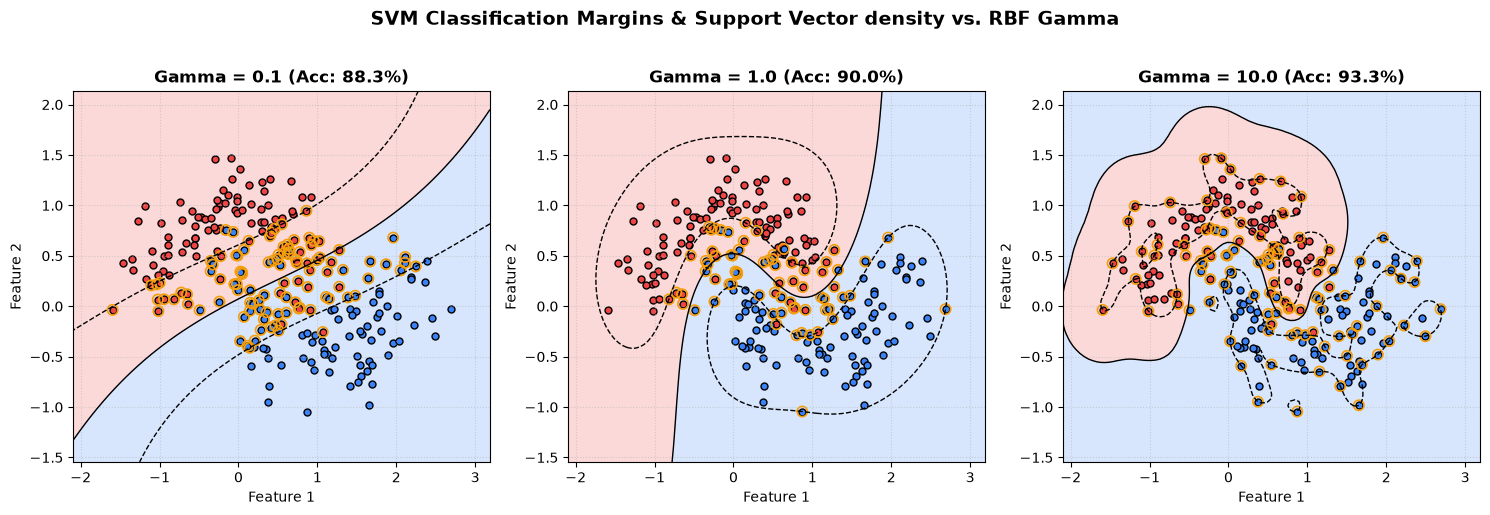

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dense grid for drawing contour boundaries
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

for idx, g in enumerate(gammas):
    ax = axes[idx]
    clf = models[g]['model']
    acc = models[g]['accuracy']
    
    # Calculate decision values
    Z = clf.decision_function(grid_points)
    Z = Z.reshape(xx.shape)
    
    # Draw classification regions and margins
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.2, colors=['#EF4444', '#3B82F6'])
    ax.contour(xx, yy, Z, colors='black', levels=[-1.0, 0.0, 1.0], linestyles=['--', '-', '--'], linewidths=1.0)
    
    # Scatter training data points
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='#EF4444', label='Class 0', edgecolors='k', s=25)
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='#3B82F6', label='Class 1', edgecolors='k', s=25)
    
    # Scatter Support Vectors
    svs = clf.support_vectors_
    ax.scatter(svs[:, 0], svs[:, 1], s=55, facecolors='none', edgecolors='#F59E0B', linewidths=1.2, label='Support Vectors')
    
    ax.set_title(f'Gamma = {g} (Acc: {acc*100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('SVM Classification Margins & Support Vector density vs. RBF Gamma', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
